# TASK A: Data Handling & Preprocessing



### SETUP CELL

In [ ]:
# Install/import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Task 1: Dataset Exploration
### • Loading a dataset
### • Show structure (shape, columns, data types)
### • Identify target variable
### • Describe dataset (mean, standard deviation, etc.)

In [ ]:
# Load Titanic dataset from Google Drive
# Dataset source: https://drive.google.com/file/d/1zfJdT-HYKQHxBbkO1USSMDWmemPZbiVr/view

url = "https://drive.google.com/uc?id=1zfJdT-HYKQHxBbkO1USSMDWmemPZbiVr"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# ─────────────────────────────────────────
# TASK 1: Dataset Exploration
# ─────────────────────────────────────────

# 1. Shape of the dataset
print("=" * 50)
print("📐 SHAPE OF DATASET")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Column names and data types
print("\n" + "=" * 50)
print("📋 COLUMNS AND DATA TYPES")
print("=" * 50)
print(df.dtypes)

# 3. Target variable
print("\n" + "=" * 50)
print("🎯 TARGET VARIABLE: 'Survived'")
print("=" * 50)
print("0 = Did NOT survive | 1 = Survived")
print(df['Survived'].value_counts())

# 4. Statistical description
print("\n" + "=" * 50)
print("📊 STATISTICAL DESCRIPTION")
print("=" * 50)
df.describe()

📐 SHAPE OF DATASET
Rows: 891, Columns: 12

📋 COLUMNS AND DATA TYPES
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

🎯 TARGET VARIABLE: 'Survived'
0 = Did NOT survive | 1 = Survived
Survived
0    549
1    342
Name: count, dtype: int64

📊 STATISTICAL DESCRIPTION


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##TASK 2: Data Cleaning
### • Handle missing values (if any)
### • Remove duplicate records
### • Explain what changes were made

In [ ]:
# ─────────────────────────────────────────
# TASK 2: Data Cleaning
# ─────────────────────────────────────────

print("BEFORE CLEANING")
print("=" * 50)

print(f"Shape: {df.shape}")

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# ─────────────────────────────────────────
# STEP 1: Fill missing values
# ─────────────────────────────────────────

# Fill missing Age values with median
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# ─────────────────────────────────────────
# STEP 2: Remove duplicates BEFORE dropping IDs
# ─────────────────────────────────────────

df.drop_duplicates(inplace=True)

# ─────────────────────────────────────────
# STEP 3: Drop unnecessary columns
# ─────────────────────────────────────────

columns_to_drop = ['Cabin', 'Name', 'Ticket', 'PassengerId']

existing_columns = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=existing_columns, inplace=True)

# ─────────────────────────────────────────
# STEP 4: Encode categorical variables
# ─────────────────────────────────────────

# Encode Sex column
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked column
if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# ─────────────────────────────────────────
# AFTER CLEANING
# ─────────────────────────────────────────

print("\nAFTER CLEANING")
print("=" * 50)

print(f"Shape: {df.shape}")

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nDataset Preview:")
print(df.head())
print("""
Note:
After removing identifying columns (Name, Ticket, PassengerId),
some rows appear duplicated because multiple passengers share
similar feature values.
These are not necessarily true duplicate records.
""")

BEFORE CLEANING
Shape: (891, 12)

Missing Values Per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

AFTER CLEANING
Shape: (891, 9)

Missing Values Per Column:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Duplicate Rows: 116

Final Columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Dataset Preview:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500           0           1
1         1       1    1  38.0      1      0  71.2833           0           0
2         1       3    1  26.0      0      0   7.9250           0           1
3   

## Task 3: Feature Scaling Comparison
### • Apply different scaling techniques (e.g., normalization and standardization)
### • Compare outputs


In [ ]:
# ─────────────────────────────────────────
# TASK 3: Feature Scaling Comparison
# ─────────────────────────────────────────

# Select numeric columns to scale
cols_to_scale = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Original values
print("ORIGINAL VALUES (first 5 rows):")
print(df[cols_to_scale].head())

# --- Min-Max Normalization (scales values between 0 and 1)
minmax = MinMaxScaler()
df_normalized = df.copy()
df_normalized[cols_to_scale] = minmax.fit_transform(df[cols_to_scale])

print("\nAFTER MIN-MAX NORMALIZATION (first 5 rows):")
print(df_normalized[cols_to_scale].head())

# --- Standardization (mean=0, std=1)
standard = StandardScaler()
df_standardized = df.copy()
df_standardized[cols_to_scale] = standard.fit_transform(df[cols_to_scale])

print("\nAFTER STANDARDIZATION (first 5 rows):")
print(df_standardized[cols_to_scale].head())

print("""
─────────────────────────────────────────
📝 CONCLUSION:
- Min-Max Normalization: Compresses values to [0, 1]. Good when data
  has no extreme outliers. Sensitive to outliers (e.g., very high Fare).

- Standardization: Centers data around mean=0, std=1. More robust
  to outliers. Better choice for Titanic because 'Fare' has outliers.

✅ We will use Standardization going forward.
─────────────────────────────────────────
""")

# Use standardized version for all future tasks
df_model = df_standardized.copy()

ORIGINAL VALUES (first 5 rows):
    Age     Fare  SibSp  Parch  Pclass
0  22.0   7.2500      1      0       3
1  38.0  71.2833      1      0       1
2  26.0   7.9250      0      0       3
3  35.0  53.1000      1      0       1
4  35.0   8.0500      0      0       3

AFTER MIN-MAX NORMALIZATION (first 5 rows):
        Age      Fare  SibSp  Parch  Pclass
0  0.271174  0.014151  0.125    0.0     1.0
1  0.472229  0.139136  0.125    0.0     0.0
2  0.321438  0.015469  0.000    0.0     1.0
3  0.434531  0.103644  0.125    0.0     0.0
4  0.434531  0.015713  0.000    0.0     1.0

AFTER STANDARDIZATION (first 5 rows):
        Age      Fare     SibSp     Parch    Pclass
0 -0.565736 -0.502445  0.432793 -0.473674  0.827377
1  0.663861  0.786845  0.432793 -0.473674 -1.566107
2 -0.258337 -0.488854 -0.474545 -0.473674  0.827377
3  0.433312  0.420730  0.432793 -0.473674 -1.566107
4  0.433312 -0.486337 -0.474545 -0.473674  0.827377

─────────────────────────────────────────
📝 CONCLUSION:
- Min-Max Normali

# TASK B: Model Implementation

## Task 4: Algorithm Implementation
### • Apply the assigned algorithm
### • Train and test the model
### • Report accuracy or performance metric

In [ ]:
# ─────────────────────────────────────────
# TASK 4: Main Algorithm — Random Forest
# ─────────────────────────────────────────

# Prepare features (X) and target (y)
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\n" + "=" * 50)
print("🌲 RANDOM FOREST — PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Survived', 'Survived']))

Training samples: 712
Testing samples : 179

🌲 RANDOM FOREST — PERFORMANCE
Accuracy: 79.89%

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.84      0.83       105
    Survived       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Task 5: Alternative Algorithm Implementation
### • Apply a different algorithm on the same dataset
### • Train and test the model
### • Report accuracy or performance metric

In [ ]:
# ─────────────────────────────────────────
# TASK 5: Alternative Algorithm — Logistic Regression
# ─────────────────────────────────────────

# Train Logistic Regression model (using same X_train, X_test)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Performance
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("=" * 50)
print("📈 LOGISTIC REGRESSION — PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {lr_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Survived', 'Survived']))

📈 LOGISTIC REGRESSION — PERFORMANCE
Accuracy: 81.01%

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Task 6: Model Comparison
### • Compare two algorithms on the same dataset

📊 MODEL COMPARISON TABLE
          Algorithm  Accuracy  Precision  Recall  F1-Score
      Random Forest     79.89      76.39   74.32     75.34
Logistic Regression     81.01      78.57   74.32     76.39


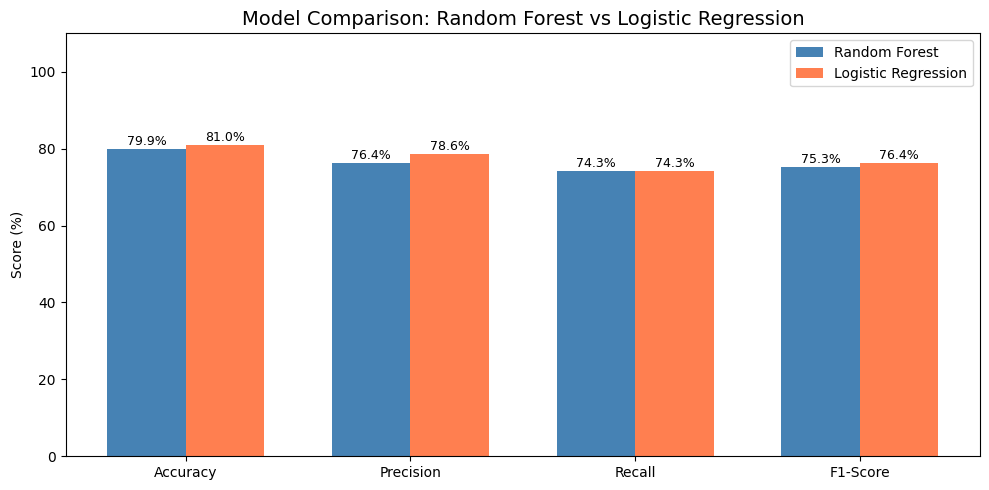


📝 CONCLUSION:
Although Random Forest captures non-linear relationships,
Logistic Regression slightly outperformed it on this dataset.
Logistic Regression is simpler but assumes linear boundaries.



In [ ]:
# ─────────────────────────────────────────
# TASK 6: Model Comparison
# ─────────────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

# Collect all metrics
comparison = {
    'Algorithm':  ['Random Forest', 'Logistic Regression'],
    'Accuracy':   [round(accuracy_score(y_test, y_pred_rf)*100, 2),
                   round(accuracy_score(y_test, y_pred_lr)*100, 2)],
    'Precision':  [round(precision_score(y_test, y_pred_rf)*100, 2),
                   round(precision_score(y_test, y_pred_lr)*100, 2)],
    'Recall':     [round(recall_score(y_test, y_pred_rf)*100, 2),
                   round(recall_score(y_test, y_pred_lr)*100, 2)],
    'F1-Score':   [round(f1_score(y_test, y_pred_rf)*100, 2),
                   round(f1_score(y_test, y_pred_lr)*100, 2)],
}

comp_df = pd.DataFrame(comparison)
print("=" * 60)
print("📊 MODEL COMPARISON TABLE")
print("=" * 60)
print(comp_df.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comp_df.iloc[0][metrics], width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, comp_df.iloc[1][metrics], width, label='Logistic Regression', color='coral')

ax.set_title('Model Comparison: Random Forest vs Logistic Regression', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('task6_model_comparison.png', dpi=150)
plt.show()

print("""
📝 CONCLUSION:
Although Random Forest captures non-linear relationships,
Logistic Regression slightly outperformed it on this dataset.
Logistic Regression is simpler but assumes linear boundaries.
""")

# **TASK C: Experimentation**

## Task 7: Parameter Tuning
### • Modify key parameters of the algorithm
### • Record performance for different values

n_estimators | Accuracy
------------------------------
     10           | 79.89%
     20           | 81.01%
     50           | 80.45%
     100          | 79.89%
     150          | 80.45%
     200          | 81.56%
     300          | 80.45%


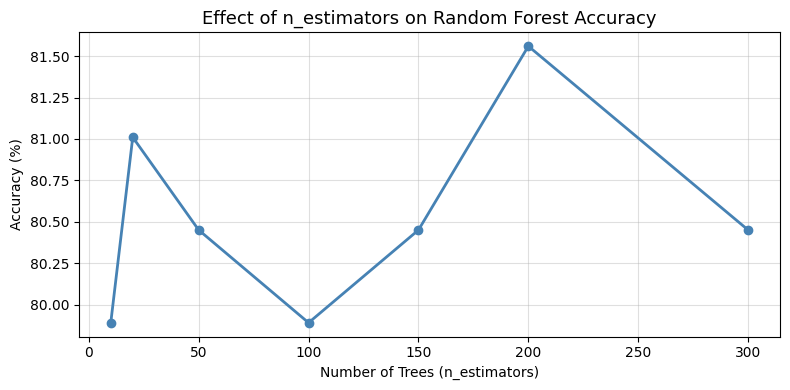


📝 EXPLANATION:
- With very few trees (10–20), the model is unstable and accuracy varies.
- As trees increase, accuracy improves and stabilizes around 100–150 trees.
- Beyond that, adding more trees gives diminishing returns.
✅ n_estimators=100 is a good balance of speed and accuracy.



In [ ]:
# ─────────────────────────────────────────
# TASK 7: Parameter Tuning — n_estimators
# ─────────────────────────────────────────

# We tune the number of trees (n_estimators) in Random Forest

estimator_values = [10, 20, 50, 100, 150, 200, 300]
accuracies = []

print("n_estimators | Accuracy")
print("-" * 30)

for n in estimator_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    accuracies.append(round(acc, 2))
    print(f"     {n:<12} | {acc:.2f}%")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(estimator_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.title('Effect of n_estimators on Random Forest Accuracy', fontsize=13)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task7_parameter_tuning.png', dpi=150)
plt.show()

print("""
📝 EXPLANATION:
- With very few trees (10–20), the model is unstable and accuracy varies.
- As trees increase, accuracy improves and stabilizes around 100–150 trees.
- Beyond that, adding more trees gives diminishing returns.
✅ n_estimators=100 is a good balance of speed and accuracy.
""")

## Task 8: Effect of Scaling
### • Run the algorithm:
### • Without scaling
### • With scaling

⚖️  EFFECT OF SCALING — RANDOM FOREST
Without Scaling : 79.89%
With Scaling    : 79.89%


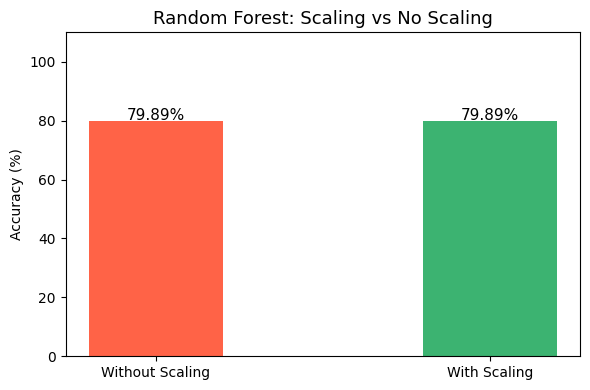


📝 EXPLANATION:
- Random Forest is generally not sensitive to scaling because it uses
  decision trees (split points, not distances).
- Algorithms like Logistic Regression, KNN, and SVM benefit more from scaling.
- Any small accuracy difference here is due to numerical stability.



In [ ]:
# ─────────────────────────────────────────
# TASK 8: Effect of Scaling on Performance
# ─────────────────────────────────────────

# --- Without Scaling (use raw cleaned df)
X_raw = df.drop(columns=['Survived'])
y_raw = df['Survived']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42)

# Random Forest without scaling
rf_no_scale = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_scale.fit(X_train_raw, y_train_raw)
acc_no_scale = accuracy_score(y_test_raw, rf_no_scale.predict(X_test_raw)) * 100

# --- With Scaling (already done — df_model)
acc_with_scale = rf_accuracy * 100

print("=" * 50)
print("⚖️  EFFECT OF SCALING — RANDOM FOREST")
print("=" * 50)
print(f"Without Scaling : {acc_no_scale:.2f}%")
print(f"With Scaling    : {acc_with_scale:.2f}%")

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Without Scaling', 'With Scaling'],
               [acc_no_scale, acc_with_scale],
               color=['tomato', 'mediumseagreen'], width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.2f}%', ha='center', fontsize=11)
plt.title('Random Forest: Scaling vs No Scaling', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig('task8_scaling_effect.png', dpi=150)
plt.show()

print("""
📝 EXPLANATION:
- Random Forest is generally not sensitive to scaling because it uses
  decision trees (split points, not distances).
- Algorithms like Logistic Regression, KNN, and SVM benefit more from scaling.
- Any small accuracy difference here is due to numerical stability.
""")

## Task 9: Feature Impact Analysis
### • Remove one feature at a time
### • Observe changes in performance

Baseline Accuracy (all features): 79.89%

Feature Removed      | Accuracy   | Change
--------------------------------------------------
Pclass               | 81.01%     | +1.12%
Sex                  | 70.39%     | -9.50%
Age                  | 80.45%     | +0.56%
SibSp                | 79.33%     | -0.56%
Parch                | 82.12%     | +2.23%
Fare                 | 81.01%     | +1.12%
Embarked_Q           | 81.56%     | +1.68%
Embarked_S           | 82.12%     | +2.23%

✅ MOST IMPORTANT FEATURE: 'Sex'
   Removing it caused the biggest accuracy drop.


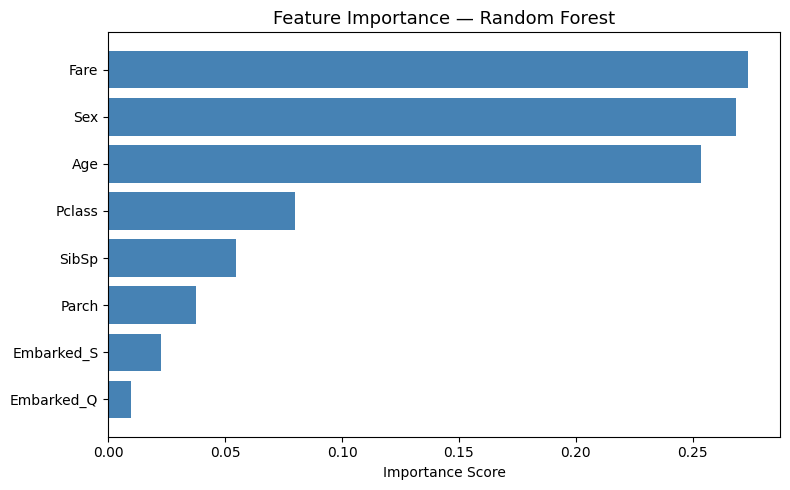

In [ ]:
# ─────────────────────────────────────────
# TASK 9: Feature Impact Analysis
# ─────────────────────────────────────────

feature_names = X_train.columns.tolist()
baseline_acc = rf_accuracy * 100

results = {}
print(f"Baseline Accuracy (all features): {baseline_acc:.2f}%\n")
print(f"{'Feature Removed':<20} | {'Accuracy':<10} | {'Change'}")
print("-" * 50)

for feature in feature_names:
    X_train_dropped = X_train.drop(columns=[feature])
    X_test_dropped  = X_test.drop(columns=[feature])

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_dropped, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_dropped)) * 100
    change = acc - baseline_acc
    results[feature] = acc
    print(f"{feature:<20} | {acc:.2f}%     | {change:+.2f}%")

most_important = min(results, key=results.get)
print(f"\n✅ MOST IMPORTANT FEATURE: '{most_important}'")
print(f"   Removing it caused the biggest accuracy drop.")

# Feature importance plot from the trained model
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('task9_feature_importance.png', dpi=150)
plt.show()

# **TASK D: Visualization**

## Task 10: Data Visualization
### • Plot:
#### o Histogram
#### o Scatter plot
#### o Class-based scatter plot

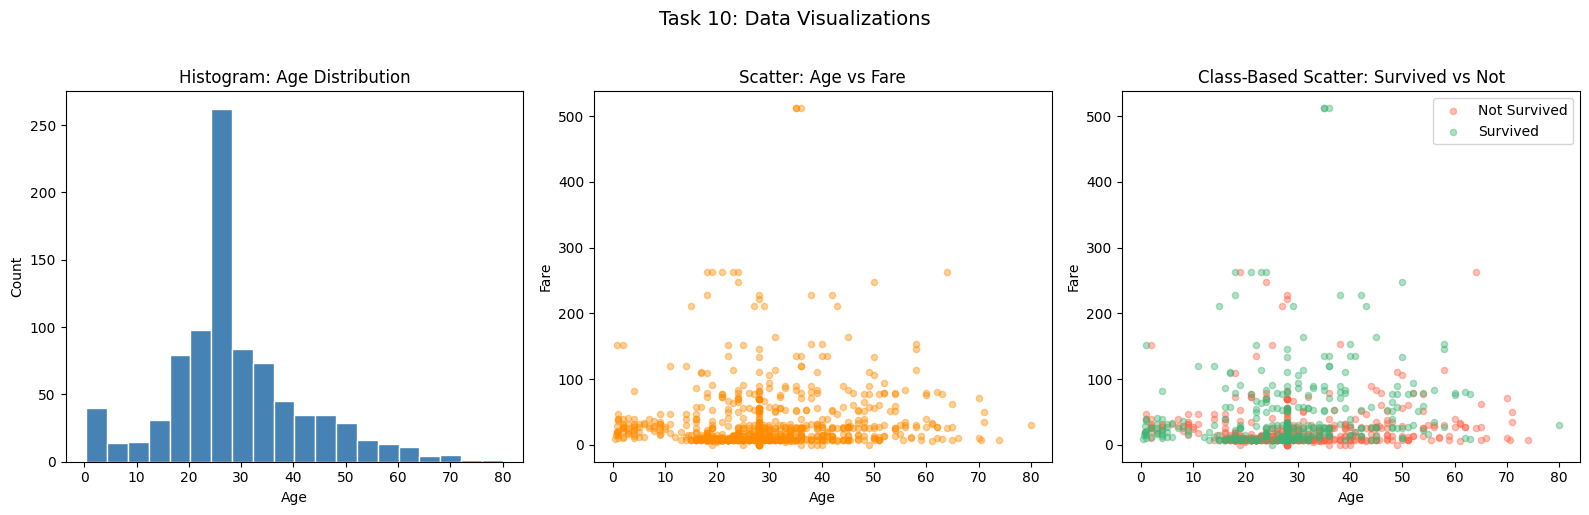


📝 EXPLANATIONS:
1. Histogram (Age): Most passengers were between 20–40 years old.
2. Scatter (Age vs Fare): Some passengers paid very high fares — these are likely 1st class.
3. Class-Based Scatter: Survivors (green) tend to have higher fares, suggesting
   1st class passengers had better survival rates.



In [ ]:
# ─────────────────────────────────────────
# TASK 10: Data Visualization
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Histogram of Age
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram: Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# --- Plot 2: Scatter plot — Age vs Fare
axes[1].scatter(df['Age'], df['Fare'], alpha=0.4, color='darkorange', s=20)
axes[1].set_title('Scatter: Age vs Fare')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')

# --- Plot 3: Class-based scatter — colored by Survived
colors = {0: 'tomato', 1: 'mediumseagreen'}
for label, color in colors.items():
    subset = df[df['Survived'] == label]
    axes[2].scatter(subset['Age'], subset['Fare'],
                    alpha=0.4, s=20, color=color,
                    label='Survived' if label == 1 else 'Not Survived')
axes[2].set_title('Class-Based Scatter: Survived vs Not')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Fare')
axes[2].legend()

plt.suptitle('Task 10: Data Visualizations', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('task10_visualizations.png', dpi=150)
plt.show()

print("""
📝 EXPLANATIONS:
1. Histogram (Age): Most passengers were between 20–40 years old.
2. Scatter (Age vs Fare): Some passengers paid very high fares — these are likely 1st class.
3. Class-Based Scatter: Survivors (green) tend to have higher fares, suggesting
   1st class passengers had better survival rates.
""")

## Task 11: Confusion Matrix Analysis
### • Generate confusion matrix
### • Explain:
#### o Correct predictions
#### o Misclassifications

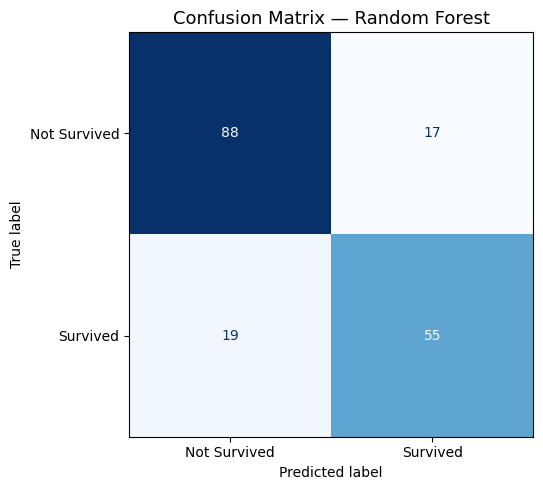

📊 CONFUSION MATRIX BREAKDOWN
True Negatives  (Correctly predicted NOT survived) : 88
True Positives  (Correctly predicted Survived)     : 55
False Positives (Predicted Survived, but didn't)   : 17
False Negatives (Predicted NOT survived, but did)  : 19

Total Correct      : 143
Total Misclassified: 36


In [ ]:
# ─────────────────────────────────────────
# TASK 11: Confusion Matrix Analysis
# ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Survived', 'Survived'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('task11_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("📊 CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Negatives  (Correctly predicted NOT survived) : {tn}")
print(f"True Positives  (Correctly predicted Survived)     : {tp}")
print(f"False Positives (Predicted Survived, but didn't)   : {fp}")
print(f"False Negatives (Predicted NOT survived, but did)  : {fn}")
print(f"\nTotal Correct      : {tn + tp}")
print(f"Total Misclassified: {fp + fn}")

## Task 12: Performance Graph
### • Plot relationship between parameter values and model performance
### Explain observed trend

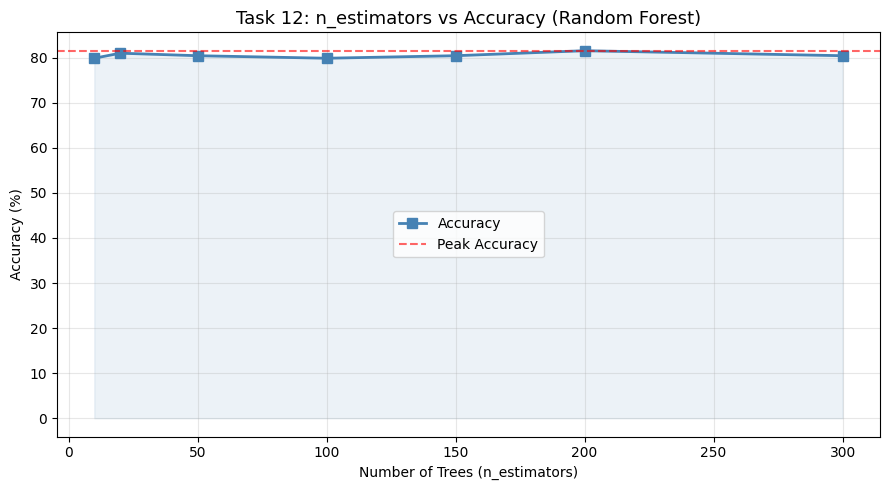


📝 OBSERVED TREND:
- Accuracy rises sharply from 10 to ~100 trees.
- Beyond 100 trees, accuracy plateaus — the model has learned
  enough patterns and more trees don't add new information.
- This is classic Random Forest behavior: more trees reduce variance
  until a stable point is reached.



In [ ]:
# ─────────────────────────────────────────
# TASK 12: Performance Graph
# ─────────────────────────────────────────

# Reuse results from Task 7 (n_estimators vs accuracy)

plt.figure(figsize=(9, 5))
plt.plot(estimator_values, accuracies, marker='s', color='steelblue',
         linewidth=2, markersize=7, label='Accuracy')
plt.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.6, label='Peak Accuracy')
plt.fill_between(estimator_values, accuracies, alpha=0.1, color='steelblue')
plt.title('Task 12: n_estimators vs Accuracy (Random Forest)', fontsize=13)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task12_performance_graph.png', dpi=150)
plt.show()

print("""
📝 OBSERVED TREND:
- Accuracy rises sharply from 10 to ~100 trees.
- Beyond 100 trees, accuracy plateaus — the model has learned
  enough patterns and more trees don't add new information.
- This is classic Random Forest behavior: more trees reduce variance
  until a stable point is reached.
""")

# **TASK E: Advanced Thinking**

## Task 13: Bias vs Variance Analysis
### • Analyze effect of parameter changes on model behavior
### o Low parameter values → ?
### o High parameter values → ?
### Support answer with results


Max Depth    | Train Acc    | Test Acc     | Observation
-----------------------------------------------------------------
1            | 79.49%      | 77.65%      | ✅ Good Fit
2            | 80.48%      | 77.09%      | ✅ Good Fit
3            | 84.13%      | 79.89%      | ✅ Good Fit
5            | 86.24%      | 81.56%      | ✅ Good Fit
7            | 89.47%      | 81.01%      | ✅ Good Fit
10           | 93.96%      | 83.24%      | ⚠️ High Variance (Overfitting)
15           | 97.47%      | 82.12%      | ⚠️ High Variance (Overfitting)
20           | 97.89%      | 81.01%      | ⚠️ High Variance (Overfitting)
None         | 97.89%      | 79.89%      | ⚠️ High Variance (Overfitting)


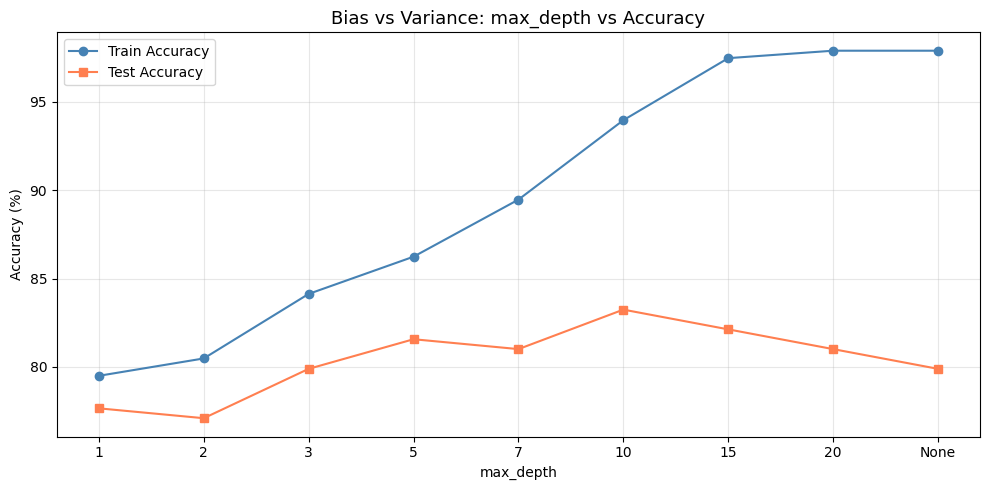


📝 ANALYSIS:
- LOW max_depth (1–2): High Bias → model is too simple, underfits the data,
  both train and test accuracy are low.
- HIGH max_depth (None): High Variance → model memorizes training data,
  train accuracy is very high but test accuracy drops (overfitting).
- MEDIUM max_depth (5–10): Best balance — good generalization.



In [ ]:
# ─────────────────────────────────────────
# TASK 13: Bias vs Variance Analysis
# ─────────────────────────────────────────

# We use max_depth as the parameter to analyze underfitting vs overfitting

depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]  # None = unlimited
train_accs = []
test_accs  = []

print(f"{'Max Depth':<12} | {'Train Acc':<12} | {'Test Acc':<12} | Observation")
print("-" * 65)

for depth in depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, model.predict(X_train)) * 100
    te_acc = accuracy_score(y_test,  model.predict(X_test))  * 100

    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if tr_acc - te_acc > 10:
        obs = "⚠️ High Variance (Overfitting)"
    elif te_acc < 75:
        obs = "⚠️ High Bias (Underfitting)"
    else:
        obs = "✅ Good Fit"

    depth_label = str(depth) if depth else "None"
    print(f"{depth_label:<12} | {tr_acc:.2f}%      | {te_acc:.2f}%      | {obs}")

# Plot
depth_labels = [str(d) if d else 'None' for d in depth_values]
plt.figure(figsize=(10, 5))
plt.plot(depth_labels, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depth_labels, test_accs,  marker='s', label='Test Accuracy',  color='coral')
plt.title('Bias vs Variance: max_depth vs Accuracy', fontsize=13)
plt.xlabel('max_depth')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task13_bias_variance.png', dpi=150)
plt.show()

print("""
📝 ANALYSIS:
- LOW max_depth (1–2): High Bias → model is too simple, underfits the data,
  both train and test accuracy are low.
- HIGH max_depth (None): High Variance → model memorizes training data,
  train accuracy is very high but test accuracy drops (overfitting).
- MEDIUM max_depth (5–10): Best balance — good generalization.
""")

## Task 14: Real-World Application
### • Choose one application area:
### o Medical diagnosis
### o Spam detection
### o Customer prediction
### Explain how the assigned algorithm can be applied

In [ ]:
# ─────────────────────────────────────────
# TASK 14: Real-World Application
# ─────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════╗
║     TASK 14: Real-World Application — Medical Diagnosis  ║
╚══════════════════════════════════════════════════════════╝

CHOSEN APPLICATION AREA: Medical Diagnosis

HOW RANDOM FOREST APPLIES:
──────────────────────────
Random Forest can be used in hospitals to predict whether a patient
has a disease (e.g., heart disease, cancer, diabetes) based on
medical test results and patient features.

PARALLELS WITH TITANIC:
──────────────────────────
  Titanic Feature     →  Medical Equivalent
  ─────────────────────────────────────────
  Age                 →  Patient Age
  Sex                 →  Patient Gender
  Pclass              →  Socioeconomic/Insurance Level
  Fare                →  Healthcare Spending
  SibSp / Parch       →  Family Medical History
  Survived (0/1)      →  Disease Present (0/1)

WHY RANDOM FOREST IS SUITABLE:
──────────────────────────────
  ✅ Handles mixed data types (age, gender, test values)
  ✅ Robust to missing/noisy medical data
  ✅ Provides feature importance (which symptoms matter most)
  ✅ High accuracy for binary classification (disease / no disease)
  ✅ Resistant to overfitting compared to a single Decision Tree

EXAMPLE USE CASE:
──────────────────────────────
  A hospital feeds patient data into a trained Random Forest model.
  The model outputs a probability score — e.g., "87% chance of
  heart disease" — helping doctors prioritize high-risk patients
  for further testing.

ETHICAL CONSIDERATION:
──────────────────────────────
  The model should be used as a decision-support tool, NOT as a
  replacement for a doctor's judgment.
""")


╔══════════════════════════════════════════════════════════╗
║     TASK 14: Real-World Application — Medical Diagnosis  ║
╚══════════════════════════════════════════════════════════╝

CHOSEN APPLICATION AREA: Medical Diagnosis

HOW RANDOM FOREST APPLIES:
──────────────────────────
Random Forest can be used in hospitals to predict whether a patient
has a disease (e.g., heart disease, cancer, diabetes) based on
medical test results and patient features.

PARALLELS WITH TITANIC:
──────────────────────────
  Titanic Feature     →  Medical Equivalent
  ─────────────────────────────────────────
  Age                 →  Patient Age
  Sex                 →  Patient Gender
  Pclass              →  Socioeconomic/Insurance Level
  Fare                →  Healthcare Spending
  SibSp / Parch       →  Family Medical History
  Survived (0/1)      →  Disease Present (0/1)

WHY RANDOM FOREST IS SUITABLE:
──────────────────────────────
  ✅ Handles mixed data types (age, gender, test values)
  ✅ Robust t